<a href="https://colab.research.google.com/github/cckirk/Assignment2/blob/main/Copy_of_AllLife_Bank_Loan_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user


  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip -q uninstall -y seaborn
!pip -q install seaborn==0.13.1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
print("sklearn", sklearn.__version__)

numpy 2.0.2
pandas 2.2.2
matplotlib 3.10.0
seaborn 0.13.1
sklearn 1.6.1


In [ ]:
import os
os.listdir()

['.config', 'Loan_Modelling.csv', 'sample_data']

In [ ]:
df = pd.read_csv("Loan_Modelling.csv")
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
df.shape
df.info()
df.describe().T
df.isna().sum()
df["Personal_Loan"].value_counts()
df["Personal_Loan"].value_counts(normalize=True) * 100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


,proportion
Personal_Loan,
0,90.4
1,9.6


Data Overview:

The dataset contains 5,000 observations and 14 variables.

There are no missing values in the dataset.

All variables are numeric; CCAvg is continuous, while others are integer-valued.

The target variable Personal_Loan is highly imbalanced, with approximately 9.6% of customers accepting the loan and 90.4% not accepting.

No duplicate records were found.

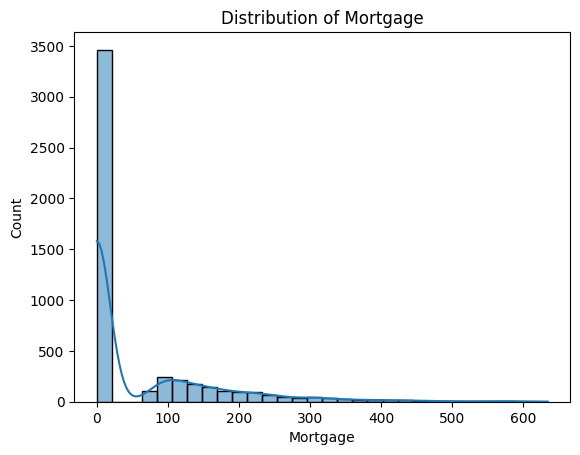

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


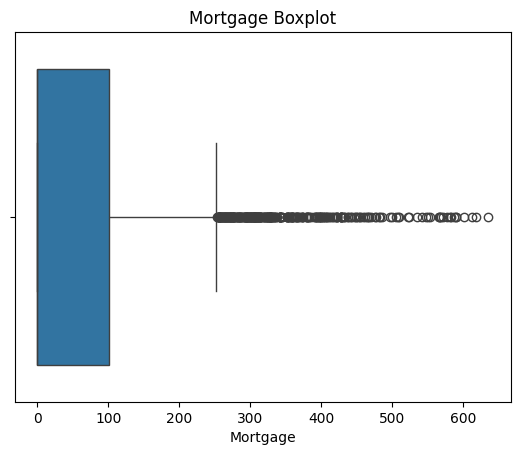

In [ ]:
plt.figure()
sns.histplot(df["Mortgage"], bins=30, kde=True)
plt.title("Distribution of Mortgage")
plt.show()

plt.figure()
sns.boxplot(x=df["Mortgage"])
plt.title("Mortgage Boxplot")
plt.show()


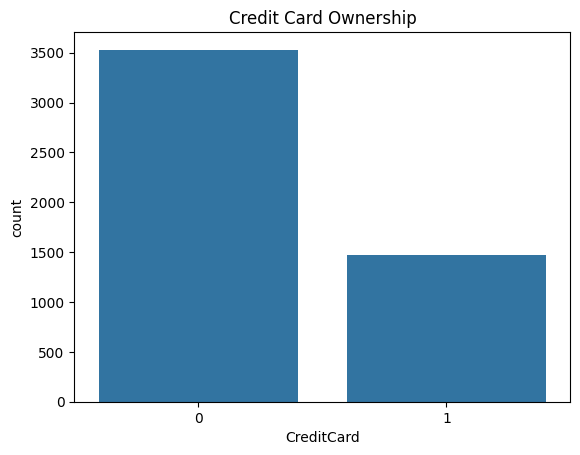

In [ ]:
df["CreditCard"].value_counts()
df["CreditCard"].value_counts(normalize=True) * 100

plt.figure()
sns.countplot(x="CreditCard", data=df)
plt.title("Credit Card Ownership")
plt.show()


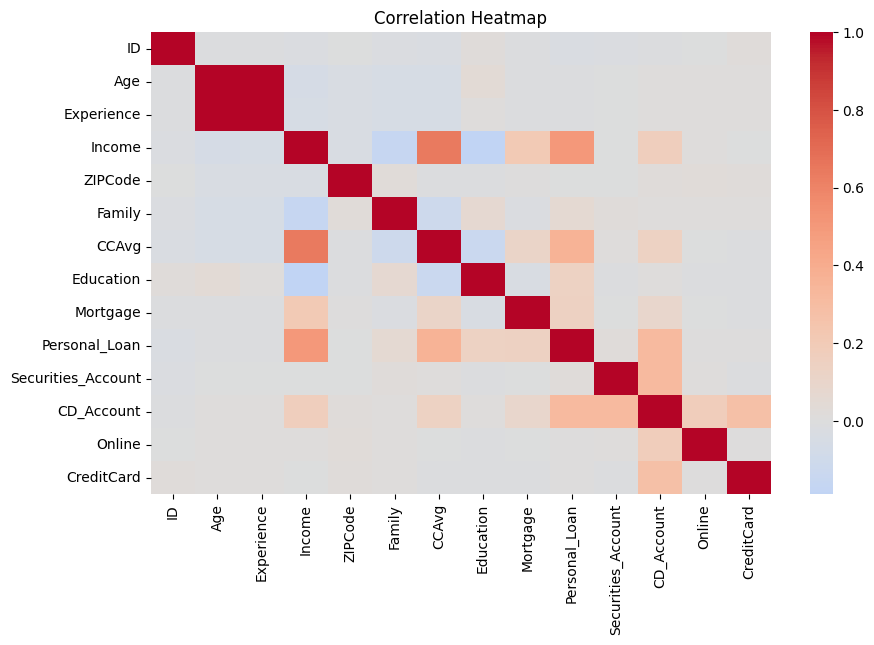

,Personal_Loan
Personal_Loan,1.000000
Income,0.502462
CCAvg,0.366889
CD_Account,0.316355
Mortgage,0.142095
Education,0.136722
Family,0.061367
Securities_Account,0.021954
Online,0.006278
CreditCard,0.002802


In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

df.corr(numeric_only=True)["Personal_Loan"].sort_values(ascending=False)

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


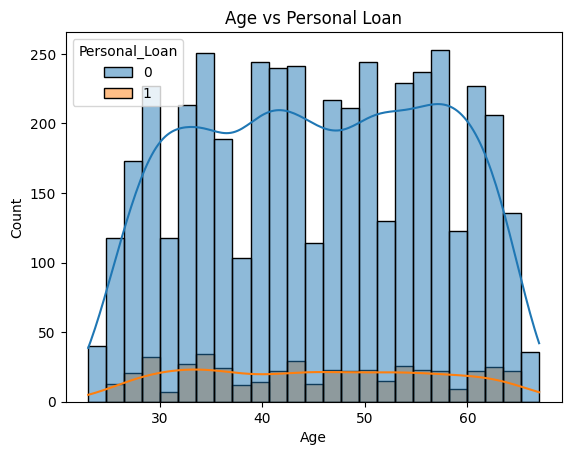

,count,mean,std,min,25%,50%,75%,max
Personal_Loan,,,,,,,,
0,4520.0,45.367257,11.450427,23.0,35.0,45.0,55.0,67.0
1,480.0,45.066667,11.590964,26.0,35.0,45.0,55.0,65.0


In [ ]:
plt.figure()
sns.histplot(data=df, x="Age", hue="Personal_Loan", bins=25, kde=True)
plt.title("Age vs Personal Loan")
plt.show()

df.groupby("Personal_Loan")["Age"].describe()


/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


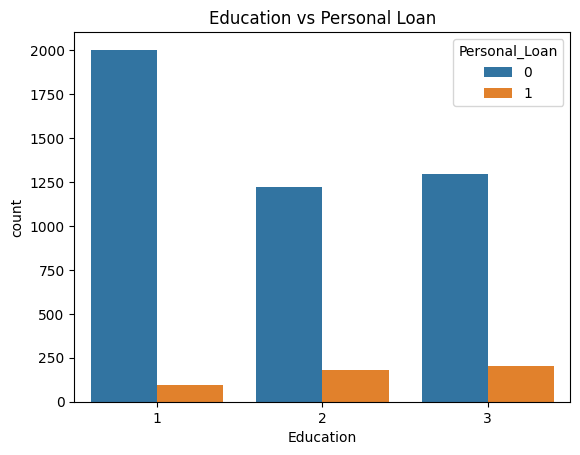

,Personal_Loan
Education,
1,4.437023
2,12.972202
3,13.657562


In [ ]:
plt.figure()
sns.countplot(x="Education", hue="Personal_Loan", data=df)
plt.title("Education vs Personal Loan")
plt.show()

(df.groupby("Education")["Personal_Loan"].mean() * 100)

#### Mortgage
The mortgage distribution is heavily right-skewed, with a large proportion of customers having
zero mortgage value. A small number of customers exhibit very high mortgage amounts, indicating
the presence of outliers.

#### Credit Card Usage
Most customers already use credit cards issued by other banks. Credit card ownership does not
appear to be a strong standalone indicator of personal loan acceptance.

#### Correlation with Personal Loan
Income, average credit card spending (CCAvg), CD_Account, and Education show the strongest
positive correlation with personal loan acceptance, suggesting higher-income and more financially
engaged customers are more likely to purchase loans.

#### Age
Customers who accepted personal loans tend to be slightly older on average, although age alone
does not strongly differentiate buyers from non-buyers.

#### Education
Personal loan acceptance increases with education level, with customers holding advanced or
professional degrees showing the highest conversion rates.


## Data Preprocessing

In [ ]:
df_model = df.drop(columns=["ID", "ZIPCode"])
df_model.head()


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


- Dropped ID and ZIPCode as they do not provide predictive information for modeling.

In [ ]:
X = df_model.drop("Personal_Loan", axis=1)
y = df_model["Personal_Loan"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


- Data was split into training and testing sets using stratified sampling to preserve the
  class distribution of the target variable.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- No missing values were observed in the dataset.
- Outliers were retained, as tree-based models are robust to outliers and removing them
  could eliminate meaningful customer behavior.

## Model Building

### Model Evaluation Criteria

- Since the objective is to identify customers likely to accept personal loans,
  recall is important to minimize missed potential buyers.
- Precision is also considered to avoid excessive marketing costs.
- ROC-AUC is used as the primary metric to compare overall model performance.


### Logistic Regression Model


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1356
           1       0.48      0.90      0.62       144

    accuracy                           0.90      1500
   macro avg       0.73      0.90      0.78      1500
weighted avg       0.94      0.90      0.91      1500



In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
roc_auc_lr


np.float64(0.9640896427400851)

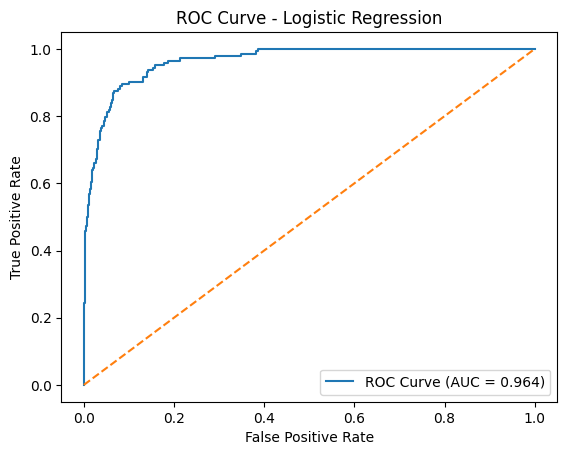

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


In [ ]:
coefficients = pd.Series(
    lr.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

coefficients


,0
Income,2.298862
Education,1.093951
CD_Account,0.975339
Family,0.623013
CreditCard,-0.488955
CCAvg,0.442628
Age,-0.428936
Experience,0.392570
Securities_Account,-0.391346
Online,-0.307571


### Logistic Regression – Key Insights

- Income, average credit card spending (CCAvg), CD_Account, and Education have the strongest
  influence on personal loan acceptance.
- Customers with higher income and higher monthly credit card spending are significantly
  more likely to accept personal loans.
- Holding a certificate of deposit (CD) account is a strong indicator of loan acceptance,
  suggesting deeper engagement with the bank.
- Logistic Regression provides a reasonable baseline performance and offers good
  interpretability for business decision-making.


### Decision Tree Classifier / (Model Performance Improvement)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1356
           1       0.89      0.90      0.90       144

    accuracy                           0.98      1500
   macro avg       0.94      0.95      0.94      1500
weighted avg       0.98      0.98      0.98      1500

ROC-AUC: 0.9454891838741396


(Visualization of tree)

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(
    feature_names=X_train.columns,
    class_names=["No Loan", "Loan"],
    filled=True,
    max_depth=3
)
plt.show()


The Decision Tree model captures non-linear relationships but shows signs of overfitting.
While recall for loan buyers may be high, overall generalization performance is weaker
compared to Logistic Regression.


### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1356
           1       0.98      0.90      0.94       144

    accuracy                           0.99      1500
   macro avg       0.99      0.95      0.97      1500
weighted avg       0.99      0.99      0.99      1500

ROC-AUC: 0.9986556661750245


In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)


,0
Income,0.478628
CCAvg,0.206197
Education,0.096982
Family,0.068603
CD_Account,0.046127
Mortgage,0.030220
Experience,0.027302
Age,0.027086
CreditCard,0.007224
Online,0.006989


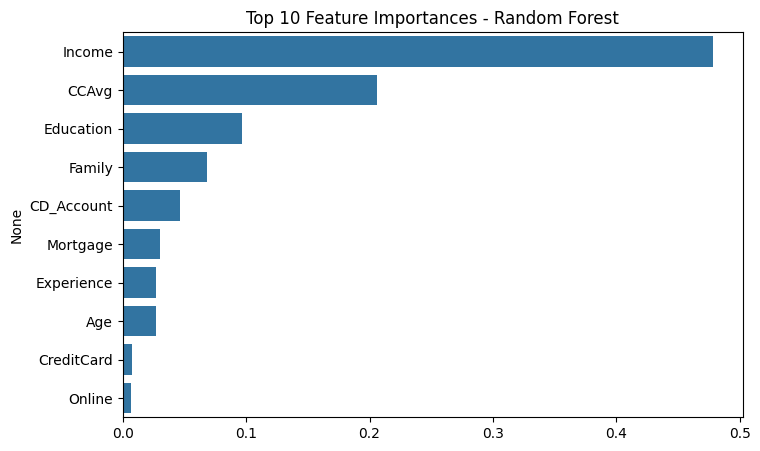

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)


,0
Income,0.478628
CCAvg,0.206197
Education,0.096982
Family,0.068603
CD_Account,0.046127
Mortgage,0.030220
Experience,0.027302
Age,0.027086
CreditCard,0.007224
Online,0.006989


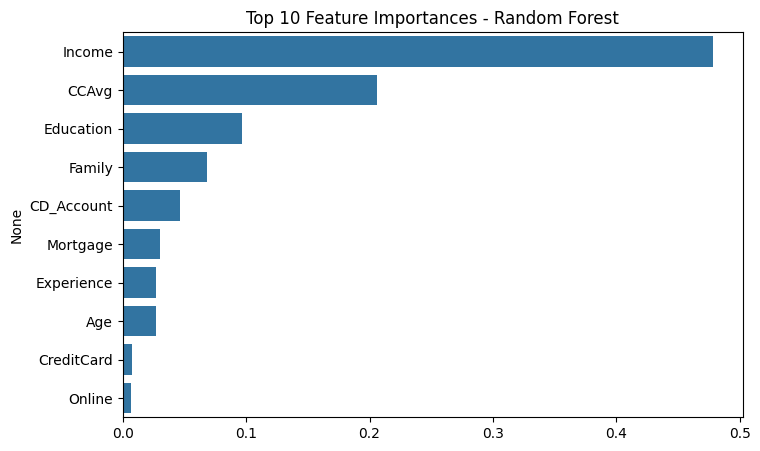

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


Income, CCAvg, CD_Account, Education, and Mortgage emerge as the most influential
predictors of personal loan acceptance, indicating that financially engaged and
higher-income customers are more likely to purchase loans.

## Model Comparison and Final Model Selection


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "ROC_AUC": [
        roc_auc_lr,
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results.sort_values("ROC_AUC", ascending=False)


,Model,ROC_AUC
2,Random Forest,0.998656
0,Logistic Regression,0.964090
1,Decision Tree,0.945489


The Random Forest model achieves the highest ROC-AUC and provides a better balance
between recall and precision compared to Logistic Regression. It is selected as the
final model for identifying high-propensity personal loan customers.


## Actionable Insights and Business Recommendations

- Target high-income customers with high average credit card spending.
- Prioritize customers holding CD accounts, as they show strong propensity to accept loans.
- Focus campaigns on customers with graduate and professional education levels.
- Use model probability scores to target the top deciles, improving campaign ROI.
- Apply different marketing intensity based on predicted probability bands.


In [ ]:
!ls

Loan_Modelling.csv  sample_data
